# 2.4 Signature scoring based on GEP signatures

Author: Xuezhu Sunny Wang

## Dataset 📊

- Bulk RNA-seq of CD138+ enriched BM cells from 12 patients

## Steps overview 📒

- Data preprocessing: convert Ensembl ids to gene names
- Use GSVA to calculate scores
- Boxplot to show scores in each treatment group



## 1. Data loading and GSVA

In [1]:
library(GSVA)
library(org.Hs.eg.db)
library(AnnotationDbi)
library(edgeR)
library(pheatmap)
library(data.table)
library(dplyr)
library(stringr)
library(readr)

Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: IRanges

Loading required package: S4Vectors

In [2]:
# =========================
# User inputs
# =========================
counts_path     <- "featureCounts.gencode_v22_rename.txt"                # your featureCounts file
signatures_csv  <- "plasma_cnmf_3_topgenes_withoutIG_k=13.csv"    # signatures CSV (drop 1st column)
min_genes_per_set <- 5                                            # require at least this many genes per set
out_scores_tsv    <- "bulk_signature_scores.tsv"                  # signatures x samples
out_coverage_tsv  <- "bulk_signature_coverage.tsv"
out_heatmap_png   <- "bulk_signature_heatmap.png"

# =========================
# Helpers
# =========================
strip_version <- function(x) sub("\\..*$", "", x)

read_featurecounts <- function(path) {
  # featureCounts typical columns: Geneid Chr Start End Strand Length <samples...>
  dt <- data.table::fread(path, data.table = FALSE)
  stopifnot("Geneid" %in% colnames(dt))
  ann_cols <- c("Geneid","Chr","Start","End","Strand","Length")
  sample_cols <- setdiff(colnames(dt), intersect(colnames(dt), ann_cols))
  counts <- dt[, c("Geneid", sample_cols), drop = FALSE]
  rownames(counts) <- counts$Geneid
  counts$Geneid <- NULL
  # coerce to numeric matrix
  M <- as.matrix(sapply(counts, as.numeric))
  rownames(M) <- rownames(counts)
  M[is.na(M)] <- 0
  M
}

ensembl_to_symbol <- function(ens_ids) {
  # map Ensembl (no version) -> SYMBOL via org.Hs.eg.db
  AnnotationDbi::mapIds(org.Hs.eg.db,
                        keys = ens_ids,
                        keytype = "ENSEMBL",
                        column = "SYMBOL",
                        multiVals = "first")
}

load_signatures_csv <- function(path) {
  df <- readr::read_csv(path, show_col_types = FALSE)
  if (ncol(df) < 2) stop("Signature CSV has <2 columns; cannot drop the first safely.")
  df <- df[, -1, drop = FALSE]  # drop first column as requested
  sets <- lapply(df, function(col) {
    genes <- unique(na.omit(trimws(as.character(col))))
    toupper(genes)
  })
  names(sets) <- colnames(df)
  sets
}

collapse_duplicates <- function(mat, new_ids) {
  # mat: genes x samples; new_ids: length(genes) vector of new rownames (e.g., SYMBOL)
  stopifnot(nrow(mat) == length(new_ids))
  keep <- !is.na(new_ids) & nzchar(new_ids)
  mat <- mat[keep, , drop = FALSE]
  new_ids <- new_ids[keep]
  # Sum duplicated symbols
  df <- as.data.frame(mat)
  df$SYMBOL <- new_ids
  agg <- df %>%
    dplyr::group_by(SYMBOL) %>%
    dplyr::summarise(across(where(is.numeric), sum, na.rm = TRUE), .groups = "drop")
  rn <- agg$SYMBOL
  agg$SYMBOL <- NULL
  M <- as.matrix(agg)
  rownames(M) <- rn
  M
}

# =========================
# 1) Load counts (Ensembl) & map to SYMBOL
# =========================
cat("Reading featureCounts...\n")
raw_counts <- read_featurecounts(counts_path)            # rows = Ensembl (possibly with versions)
ens_novers <- strip_version(rownames(raw_counts))
cat("Mapping Ensembl (n=", length(ens_novers), ") to HGNC symbols via org.Hs.eg.db...\n", sep = "")
ens2sym <- ensembl_to_symbol(ens_novers)

# Build a SYMBOL-indexed matrix
cat("Collapsing duplicates by SYMBOL (sum)...\n")
sym_counts <- collapse_duplicates(raw_counts, ens2sym)
cat("Counts matrix after SYMBOL mapping:", nrow(sym_counts), "genes x", ncol(sym_counts), "samples\n")

# =========================
# 2) Normalize to CPM and log-transform for GSVA
# =========================
cat("Normalizing to CPM and computing log2(CPM+1)...\n")
# edgeR CPM
cpm_mat <- edgeR::cpm(sym_counts, log = FALSE, prior.count = 0)
logcpm  <- log2(cpm_mat + 1)

# (GSVA expects genes x samples)
stopifnot(all(rownames(logcpm) == rownames(cpm_mat)))

# =========================
# 3) Load gene signatures & compute coverage
# =========================
cat("Loading signatures...\n")
gene_sets <- load_signatures_csv(signatures_csv)   # named list: set -> character vector of SYMBOLS (upper)
universe  <- toupper(rownames(logcpm))

coverage <- lapply(names(gene_sets), function(nm) {
  g  <- gene_sets[[nm]]
  ok <- intersect(g, universe)
  data.frame(signature = nm,
             n_genes_total = length(g),
             n_genes_found = length(ok),
             fraction_found = ifelse(length(g) > 0, length(ok)/length(g), NA_real_))
})
coverage_df <- do.call(rbind, coverage) |> dplyr::arrange(fraction_found)
readr::write_tsv(coverage_df, out_coverage_tsv)
cat("Coverage saved to:", out_coverage_tsv, "\n")

# Optionally filter sets with too few recovered genes
enough_genes <- coverage_df$signature[coverage_df$n_genes_found >= min_genes_per_set]
if (length(enough_genes) == 0) {
  warning("No signatures meet min_genes_per_set; proceeding with all sets (you can raise min_genes_per_set later).")
  enough_genes <- coverage_df$signature
}
gene_sets_f <- gene_sets[enough_genes]

# =========================
# 4) Run GSVA (regular GSVA; Gaussian kernel for continuous logCPM)
# =========================
cat("Running GSVA on", length(gene_sets_f), "signatures...\n")
# GSVA input must be a matrix genes x samples
expr_for_gsva <- as.matrix(logcpm)
mode(expr_for_gsva) <- "numeric"

# Ensure each set contains genes present in the expr matrix
gene_sets_f <- lapply(gene_sets_f, function(g) intersect(g, rownames(expr_for_gsva)))

# Run GSVA (regular)
scores <- GSVA::gsva(expr_for_gsva, gene_sets_f,
                     method = "gsva",
                     kcdf   = "Gaussian",
                     mx.diff = TRUE,    # classic GSVA enrichment
                     parallel.sz = 1)
# scores: signatures x samples
cat("GSVA complete. Score matrix:", dim(scores)[1], "signatures x", dim(scores)[2], "samples\n")

# Save scores (samples x signatures)
readr::write_tsv(as.data.frame(t(scores)), out_scores_tsv)
cat("Scores saved to:", out_scores_tsv, "\n")


Reading featureCounts...
Mapping Ensembl (n=60483) to HGNC symbols via org.Hs.eg.db...


'select()' returned 1:many mapping between keys and columns



Collapsing duplicates by SYMBOL (sum)...


Warning message:
“There was 1 warning in `dplyr::summarise()`.
ℹ In argument: `across(where(is.numeric), sum, na.rm = TRUE)`.
ℹ In group 1: `SYMBOL = "A1BG"`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


Counts matrix after SYMBOL mapping: 35014 genes x 12 samples
Normalizing to CPM and computing log2(CPM+1)...
Loading signatures...


New names:
• `` -> `...1`


Coverage saved to: bulk_signature_coverage.tsv 
Running GSVA on 13 signatures...


Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“9834 genes with constant expression values throughout the samples.”
Warning message in .filterFeatures(expr, method):
“Since argument method!="ssgsea", genes with constant expression values are discarded.”


Estimating GSVA scores for 13 gene sets.
Estimating ECDFs with Gaussian kernels
  |======================================================================| 100%

GSVA complete. Score matrix: 13 signatures x 12 samples
Scores saved to: bulk_signature_scores.tsv 


## 2. Boxplot

In [3]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(rstatix)    
library(ggpubr)    
library(tibble)


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand



Attaching package: ‘rstatix’


The following object is masked from ‘package:AnnotationDbi’:

    select


The following object is masked from ‘package:IRanges’:

    desc


The following object is masked from ‘package:stats’:

    filter




In [4]:
options(repr.plot.height=20,repr.plot.width=20)

# ---------- 1) Long format + drop VCD ----------
df_long <- as.data.frame(scores) %>%
  dplyr::select(-any_of("VCD")) %>%
  rownames_to_column("signature") %>%
  pivot_longer(-signature, names_to = "sample", values_to = "score")

# ---------- 2) Good/Poor groups ----------
poor_samples <- c("BulkAL5", "BulkAL6", "BulkAL7")
df_long <- df_long %>%
  mutate(group = if_else(sample %in% poor_samples, "Poor", "Good"),
         group = factor(group, levels = c("Good","Poor")))

# ---------- 3) Per-signature Wilcoxon tests (raw p shown on plot) ----------
stats <- df_long %>%
  group_by(signature) %>%
  wilcox_test(score ~ group, detailed = TRUE) %>%
  # Add positions for ggpubr labels (per facet)
  add_xy_position(x = "group", dodge = 0.1) %>%
  # Nicely formatted "Wilcoxon p = ..." labels
  mutate(label = sprintf("Wilcoxon p = %.3g", p))


In [5]:
library(dplyr)

df_keep <- df_long %>%
  filter(signature %in% c("1","4"))


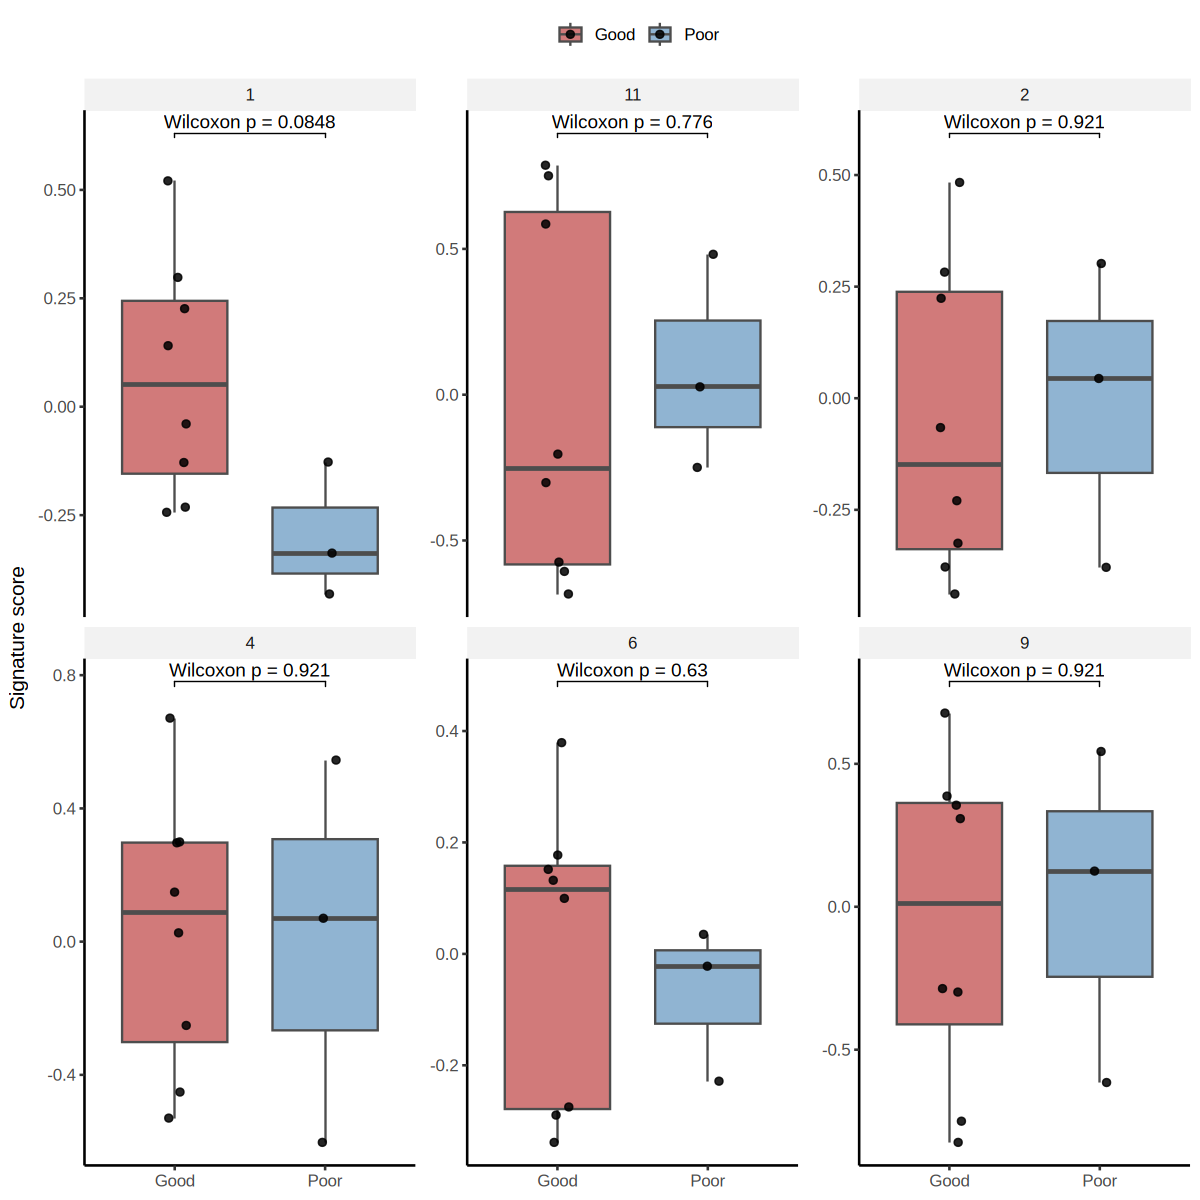

In [6]:
options(repr.plot.height=10,repr.plot.width=10)

# ---------- 2) Good/Poor groups ----------
poor_samples <- c("BulkAL5", "BulkAL6", "BulkAL7")
df_long <- df_long %>%
  mutate(group = if_else(sample %in% poor_samples, "Poor", "Good"),
         group = factor(group, levels = c("Good","Poor")))

df_keep <- df_long %>%
  filter(signature %in% c("1", "2","11","6","9","4"))


# ---------- 3) Per-signature Wilcoxon tests (raw p shown on plot) ----------
stats <- df_keep %>%
  group_by(signature) %>%
  wilcox_test(score ~ group, detailed = TRUE) %>%
  # Add positions for ggpubr labels (per facet)
  add_xy_position(x = "group", dodge = 0.1) %>%
  # Nicely formatted "Wilcoxon p = ..." labels
  mutate(label = sprintf("Wilcoxon p = %.3g", p))

# ---------- 4) Boxplots with colors similar to your figure ----------
COLS <- c(Good = "firebrick",  # soft green
          Poor = "steelblue")  # brick red

p <- ggplot(df_keep, aes(group, score, fill = group)) +
  geom_boxplot(width = 0.7, alpha = 0.6, outlier.shape = NA, color = "grey30") +
  geom_jitter(width = 0.08, size = 1.6, alpha = 0.85) +
  facet_wrap(~ signature, scales = "free_y") +
  ggpubr::stat_pvalue_manual(
    stats,
    label = "label",          # shows "Wilcoxon p = ..."
    hide.ns = FALSE,          # show all p-values
    tip.length = 0.01
  ) +
  scale_fill_manual(values = COLS) +
  labs(x = NULL, y = "Signature score", fill = NULL) +
  theme_classic(base_size = 12) +
  theme(
    strip.background = element_rect(fill = "grey95", colour = NA),
    panel.grid.minor = element_blank(),
    legend.position = "top"
  )

print(p)


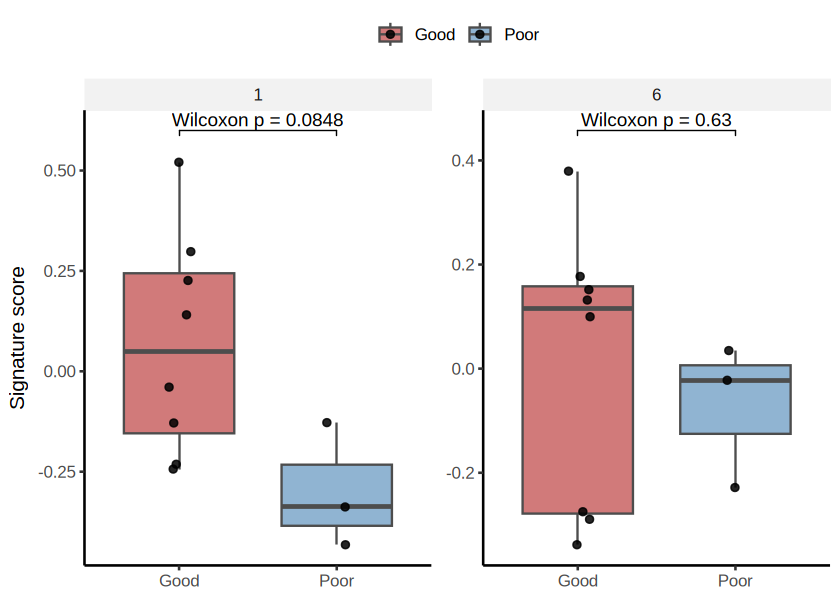

In [11]:
options(repr.plot.height=5,repr.plot.width=7)

# ---------- 2) Good/Poor groups ----------
poor_samples <- c("BulkAL5", "BulkAL6", "BulkAL7")
df_long <- df_long %>%
  mutate(group = if_else(sample %in% poor_samples, "Poor", "Good"),
         group = factor(group, levels = c("Good","Poor")))

df_keep <- df_long %>%
  filter(signature %in% c("1", "6"))


# ---------- 3) Per-signature Wilcoxon tests (raw p shown on plot) ----------
stats <- df_keep %>%
  group_by(signature) %>%
  wilcox_test(score ~ group, detailed = TRUE) %>%
  # Add positions for ggpubr labels (per facet)
  add_xy_position(x = "group", dodge = 0.1) %>%
  # Nicely formatted "Wilcoxon p = ..." labels
  mutate(label = sprintf("Wilcoxon p = %.3g", p))

# ---------- 4) Boxplots with colors similar to your figure ----------
COLS <- c(Good = "firebrick",  # soft green
          Poor = "steelblue")  # brick red

p <- ggplot(df_keep, aes(group, score, fill = group)) +
  geom_boxplot(width = 0.7, alpha = 0.6, outlier.shape = NA, color = "grey30") +
  geom_jitter(width = 0.08, size = 1.6, alpha = 0.85) +
  facet_wrap(~ signature, scales = "free_y") +
  ggpubr::stat_pvalue_manual(
    stats,
    label = "label",          # shows "Wilcoxon p = ..."
    hide.ns = FALSE,          # show all p-values
    tip.length = 0.01
  ) +
  scale_fill_manual(values = COLS) +
  labs(x = NULL, y = "Signature score", fill = NULL) +
  theme_classic(base_size = 12) +
  theme(
    strip.background = element_rect(fill = "grey95", colour = NA),
    panel.grid.minor = element_blank(),
    legend.position = "top"
  )

print(p)
